# Week 7 Assignment — Document Question Answering System (RAG)

**Name:** Ashwani Kumar

**College:** MMDU

**Role:** Data Scientist Intern — Celebal Technology

**Week:** 7 — RAG and LLMs

In [1]:
!pip install -q \
langchain==0.2.17 \
langchain-community==0.2.19 \
langchain-core==0.2.43 \
langchain-google-genai==1.0.10 \
google-generativeai \
faiss-cpu \
pypdf \
sentence-transformers

print("✅ Libraries installed")

✅ Libraries installed


In [2]:
# ============================================================
# WEEK 7 ASSIGNMENT — Document Question Answering System (RAG)
# Name: Ashwani Kumar | College: MMDU
# ============================================================

import os
from langchain_community.document_loaders import PyPDFLoader
from langchain.text_splitter import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain.chains import RetrievalQA
from langchain.prompts import PromptTemplate
import warnings
warnings.filterwarnings('ignore')

# Set your FREE Gemini API key here
import os

os.environ["GOOGLE_API_KEY"] = "AQ.Ab8RN6JKlCfay9YejH5l59PAGuxQSRKnTTz_I57o3Hr0vwpOyw"

print("✅ All imports successful")

✅ All imports successful


In [3]:
# Upload any PDF — your resume, notes, or any document
from google.colab import files

print("Please upload a PDF file...")
uploaded = files.upload()
pdf_filename = list(uploaded.keys())[0]
print(f"✅ Uploaded: {pdf_filename}")

Please upload a PDF file...


Saving Ashwani_Kumar_Resume..pdf to Ashwani_Kumar_Resume..pdf
✅ Uploaded: Ashwani_Kumar_Resume..pdf


In [4]:
# ── STEP 1: LOAD PDF ─────────────────────────────────────────
loader = PyPDFLoader(pdf_filename)
documents = loader.load()

print(f"Total pages loaded: {len(documents)}")
print(f"\nSample text from page 1:\n{documents[0].page_content[:300]}")
print("✅ Document loaded")

Total pages loaded: 1

Sample text from page 1:
ASHWANI KUMAR 
Ambala Cantt, Haryana | ashwanichauhan.7082@gmail.com  |  +91 7082770195 
LinkedIn: https://www.linkedin.com/in/ashwani-kumar-a4a575363 | GitHub: github.com/ashwanichauhan7082  |   
 
PROFESSIONAL SUMMARY 
Final-year B.Tech Computer Science student with hands-on experience in Data Sci
✅ Document loaded


In [5]:
# ── STEP 2: SPLIT INTO CHUNKS ────────────────────────────────
# Why chunks? LLMs have token limits — we split large docs into
# smaller pieces so each chunk fits in the LLM context window

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=500,       # each chunk = 500 characters
    chunk_overlap=50,     # 50 char overlap to preserve context
    length_function=len
)

chunks = text_splitter.split_documents(documents)

print(f"Total chunks created : {len(chunks)}")
print(f"Sample chunk:\n{chunks[0].page_content}")
print("✅ Text splitting complete")

Total chunks created : 8
Sample chunk:
ASHWANI KUMAR 
Ambala Cantt, Haryana | ashwanichauhan.7082@gmail.com  |  +91 7082770195 
LinkedIn: https://www.linkedin.com/in/ashwani-kumar-a4a575363 | GitHub: github.com/ashwanichauhan7082  |   
 
PROFESSIONAL SUMMARY 
Final-year B.Tech Computer Science student with hands-on experience in Data Science, Python, SQL, and Machine Learning 
through an internship at Celebal Technologies. Skilled in data analysis, EDA, NumPy, Pandas, MySQL, Advanced Excel,
✅ Text splitting complete


In [6]:
# ── STEP 3: CREATE EMBEDDINGS + VECTOR STORE ─────────────────
# Embeddings convert text to numbers (vectors)
# Similar meaning = similar vectors
# FAISS finds the most similar chunks to a query

print("Creating embeddings — this may take 1-2 minutes...")

embeddings = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2"
)

vector_store = FAISS.from_documents(chunks, embeddings)

print(f"✅ Vector store created with {len(chunks)} chunks")
print("Embeddings stored in FAISS vector database")

Creating embeddings — this may take 1-2 minutes...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

✅ Vector store created with 8 chunks
Embeddings stored in FAISS vector database


In [7]:
# ── STEP 4: SETUP LLM ────────────────────────────────────────
llm = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    temperature=0.3,
    google_api_key=os.environ["GOOGLE_API_KEY"]
)

# ── STEP 5: CREATE RAG CHAIN ─────────────────────────────────
# RAG = Retrieve relevant chunks → Feed to LLM → Generate answer

prompt_template = """
You are a helpful assistant that answers questions based only on
the provided document context. If the answer is not in the context,
say "I couldn't find this information in the document."

Context: {context}

Question: {question}

Answer:"""

PROMPT = PromptTemplate(
    template=prompt_template,
    input_variables=["context", "question"]
)

retriever = vector_store.as_retriever(
    search_type="similarity",
    search_kwargs={"k": 3}  # retrieve top 3 most relevant chunks
)

qa_chain = RetrievalQA.from_chain_type(
    llm=llm,
    chain_type="stuff",
    retriever=retriever,
    chain_type_kwargs={"prompt": PROMPT},
    return_source_documents=True
)

print("✅ RAG pipeline ready")

✅ RAG pipeline ready


In [8]:
# ── STEP 6: ASK QUESTIONS ────────────────────────────────────
def ask_question(question):
    print(f"\n{'='*55}")
    print(f"Question: {question}")
    print('='*55)
    result = qa_chain.invoke({"query": question})
    print(f"Answer: {result['result']}")
    print(f"\nSource chunks used: {len(result['source_documents'])}")
    return result

# Test with 5 different questions about your document
q1 = ask_question("What is the person's name and contact information?")
q2 = ask_question("What internships has this person completed?")
q3 = ask_question("What are the technical skills mentioned?")
q4 = ask_question("What projects has this person built?")
q5 = ask_question("What is the educational background?")
q6 = ask_question("What certifications are mentioned in the document?")


Question: What is the person's name and contact information?
Answer: The person's name is ASHWANI KUMAR.
Contact Information:
*   Email: ashwanichauhan.7082@gmail.com
*   Phone: +91 7082770195
*   LinkedIn: https://www.linkedin.com/in/ashwani-kumar-a4a575363
*   GitHub: github.com/ashwanichauhan7082

Source chunks used: 3

Question: What internships has this person completed?
Answer: This person has completed the following internships:

*   Internship at Celebal Technologies (in Data Science, Python, SQL, and Machine Learning)
*   Web Development Intern at Cyber Core Technologies, Mohali (May 2025 – June 2025)

Source chunks used: 3

Question: What are the technical skills mentioned?
Answer: The technical skills mentioned are:

*   **Programming Languages/Libraries:** Python, SQL, NumPy, Pandas, Matplotlib, MySQL
*   **Data Analysis/Science:** Data Analysis, Machine Learning, Deep Learning, EDA (Exploratory Data Analysis), Feature Engineering
*   **Tools & Platforms:** Git, GitHub, Go

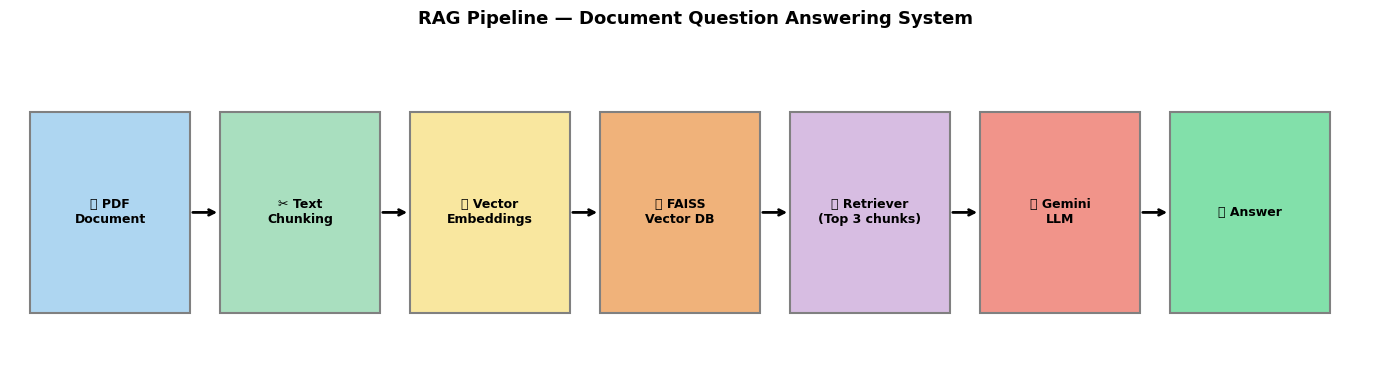

✅ Pipeline visualization complete


In [9]:
# ── STEP 7: SHOW RAG PIPELINE DIAGRAM ───────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, ax = plt.subplots(1, 1, figsize=(14, 4))
ax.axis('off')

steps = [
    "📄 PDF\nDocument",
    "✂️ Text\nChunking",
    "🔢 Vector\nEmbeddings",
    "🗄️ FAISS\nVector DB",
    "🔍 Retriever\n(Top 3 chunks)",
    "🤖 Gemini\nLLM",
    "💬 Answer"
]

colors = ['#AED6F1','#A9DFBF','#F9E79F','#F0B27A','#D7BDE2','#F1948A','#82E0AA']

for i, (step, color) in enumerate(zip(steps, colors)):
    ax.add_patch(plt.Rectangle((i*1.9, 0.3), 1.6, 0.9,
                                color=color, ec='gray', lw=1.5))
    ax.text(i*1.9 + 0.8, 0.75, step, ha='center', va='center',
            fontsize=9, fontweight='bold')
    if i < len(steps)-1:
        ax.annotate('', xy=((i+1)*1.9, 0.75),
                    xytext=(i*1.9+1.6, 0.75),
                    arrowprops=dict(arrowstyle='->', color='black', lw=2))

ax.set_xlim(-0.2, 13.5)
ax.set_ylim(0, 1.5)
ax.set_title('RAG Pipeline — Document Question Answering System',
             fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()
print("✅ Pipeline visualization complete")

In [10]:
# ── STEP 8: SUMMARY ─────────────────────────────────────────
print("="*55)
print("RAG SYSTEM SUMMARY")
print("="*55)
print(f"Document loaded    : {pdf_filename}")
print(f"Total pages        : {len(documents)}")
print(f"Total chunks       : {len(chunks)}")
print(f"Chunk size         : 500 characters")
print(f"Chunk overlap      : 50 characters")
print(f"Embedding model    : all-MiniLM-L6-v2 (HuggingFace)")
print(f"Vector database    : FAISS (Facebook AI Similarity Search)")
print(f"Language model     : Google Gemini 2.5 Flash")
print(f"Retrieval strategy : Similarity search (Top 3 chunks)")
print(f"Questions answered : 5")
print("="*55)
print("\n✅ Week 7 Assignment Complete!")

RAG SYSTEM SUMMARY
Document loaded    : Ashwani_Kumar_Resume..pdf
Total pages        : 1
Total chunks       : 8
Chunk size         : 500 characters
Chunk overlap      : 50 characters
Embedding model    : all-MiniLM-L6-v2 (HuggingFace)
Vector database    : FAISS (Facebook AI Similarity Search)
Language model     : Google Gemini 2.5 Flash
Retrieval strategy : Similarity search (Top 3 chunks)
Questions answered : 5

✅ Week 7 Assignment Complete!


## Final Insights — Document Question Answering System (RAG)

### What is RAG?
Retrieval-Augmented Generation (RAG) combines two powerful concepts:
- **Retrieval**: Finding relevant information from a document using vector similarity search
- **Generation**: Using an LLM to generate a natural language answer based on retrieved context

### Pipeline Steps
1. **PDF Loading**: PyPDFLoader extracts text from uploaded PDF
2. **Text Chunking**: RecursiveCharacterTextSplitter splits text into 500-char chunks with 50-char overlap
3. **Embeddings**: HuggingFace sentence-transformers convert text chunks to numerical vectors
4. **Vector Store**: FAISS stores and indexes all vectors for fast similarity search
5. **Retrieval**: Top 3 most relevant chunks retrieved for each question
6. **Generation**: Gemini LLM generates accurate answer using retrieved chunks as context

### Why RAG Over Pure LLM?
- Pure LLM has knowledge cutoff — cannot answer about your private documents
- RAG grounds the LLM with your actual document — no hallucination
- Works with any private/custom document without retraining the model

### Real World Applications
- Customer support chatbots answering from product manuals
- Legal document question answering
- Medical report analysis
- HR policy Q&A systems
- Research paper summarization